In [87]:
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from scipy.optimize import root
from scipy.integrate import solve_ivp

E_A = 72500      # activation energy J/mol
k_0 = 5.01E06       # pre-exponential factor 1/s
R = 8.314        # gas constant J/(mol K)
H_R = -92200     # reaction enthalpy J/mol

d_R = 0.03       # tube diameter m
L_R = 300        # reactor length m
h_wall = 500     # wall heat transfer coefficient W/(m^2 K)  [= 0.5 kJ/(s m^2 K)]

u_ref = 1

a_wall = 4 / d_R           # specific wall area m^2_wall/m^3_reactor  (= pi*d / (pi*d^2/4))

A_ref = np.pi * d_R ** 2 / 4

def kinetics(T, c_1):
    """Arrhenius reaction rate, first order in c_1."""
    k_1 = k_0 * np.exp(-E_A / (R * T))   # rate constant 1/s
    r = k_1 * c_1                          # reaction rate mol/(m^3 s)
    return r

Lspan = np.array([0, L_R])
leval = np.linspace(0, Lspan[1], 2001)


# Initial conditions (= inlet conditions for PFTR)
c_10 = 2270      # inlet concentration EO mol/m^3
c_20 = 0         # inlet concentration EG mol/m^3
T_0 = 423        # inlet temperature K
T_wall = 423     # wall temperature K (fixed, independent of position)



### Adapting the thermodynamics
The given heat capacity $c_p = 4.19$ kJ mol $^{-1}$ K $^{-1}$ and density $\rho = 1000$ kg m $^{-3}$ describe the properties of water. But in reality the mixture behaves thermodynamically differently depending on the local composition and temperature. This can lead to large deviations and thus potentially large errors. In literature the hydrogenation of EO is often described as a liquid-phase reaction taking place at higher pressures [cite]. This allows the use of correlations for saturated liquids. The approximation error increases near the critical temperatures, which limits the range of reliable temperatures. For this investigation, the highest available temperature values were chosen when the range was exceeded.

### Calculation of the heat capacity
The heat capacities of the pure components water and EG are calculated using the VDI heat atlas correlation for saturated liquids (Equation 1 and Table 1). 

$$
 c_{p,i}(T) = R_i \cdot \left[\frac{A_i}{1 - \frac{T}{T_{C,i}}} + B_i + C_i\left(1 - \frac{T}{T_{C,i}}\right) + D_i\left(1 - \frac{T}{T_{C,i}}\right)^2 + E_i\left(1 - \frac{T}{T_{C,i}}\right)^3 + F_i\left(1 - \frac{T}{T_{C,i}}\right)^4\right] \times 1000 \tag{1}
$$

This correlation uses the specific gas constant $R_i = \frac{R}{M_i}$.

Table 1: Parameters for the heat capacities of liquids
| | $T_{C}$ (K) | A | B | C | D | E | F | Temperature range (°C) |
| --------------- | --------------- | --------------- | ------------------------- | ------------------------- |  ------------------------- | ------------------------- | ------------------------- | ------------------------- | 
| Water | 647.10 | 0.2399 | 12.8647 | -33.6392 | 104.7686 | -155.4709 | 92.3726 | 0 - 250|
| EG | 724.05 | 0 | 33.1585 | -25.9580 | 0 | 0 | 0 | 0 - 200 |
| EO | 469.15 | - | - | - | - | - | - | - |

For EO there are no parameters available for the correlation in the relevant temperature range. Therefore interpolated data are used (Table 2).

Table 2: Measured heat capacities for EO [cite]
| $T$ (°C) | -40 | -20 | 0 | 20 | 40 | 60 | 80 | 100 |
|---|---|---|---|---|---|---|---|---|
| $c_{p,\mathrm{EO}}$ (J kg $^{-1}$ K $^{-1}$ ) | 1880 | 1910 | 1950 | 2000 | 2060 | 2150 | 2270 | 2400 |

For the mixture heat capacity, an ideal mixture and weight fractions are used because the property is mass-specific (Equation 2). 

$$ c_{p,mix} = \sum_i w_i c_{p,i}  \tag{2}$$

Because molar fractions are easier to calculate, mass fractions are obtained using Equation 3.

$$
w_i = \frac{x_i \, M_i}{\sum_j x_j \, M_j} \tag{3}
$$

### Calculation of the density
The densities of the pure components water, EG and EO are calculated using the VDI heat atlas correlation for saturated liquids (Equation 4 and Table 3). 

$$
\rho_i(T) = \rho_{i,c} + A_i \left(1 - \frac{T}{T_{C,i}}\right)^{0.35} + B_i \left(1 - \frac{T}{T_{C,i}}\right)^{2/3} + C_i \left(1 - \frac{T}{T_{C,i}}\right) + D_i \left(1 - \frac{T}{T_{C,i}}\right)^{4/3} \tag{4}
$$

Table 3: Parameters for the density of liquids
| | $\rho_{i,c}$ (kg/m³) | A | B | C | D | Temperature range (°C) |
|---|---|---|---|---|---|--|
| Water | 322 | 1094.0233 | -1813.2295 | 3863.9557 | -2479.8130 | 0 - 250|
| EG | 325 | 1305.5931 | -1374.2561 | 1691.0501 | -665.0358 | 0 - 250 |
| EO | 314 | 757.9994 | -286.5638 | 583.1649 | -177.0206 | -50 - 150 |

For mixing behavior, an ideal mixture is assumed. The mixture density is calculated using Equation 5. The mass fractions are computed from Equation 3.

$$
\rho_{mix} = \frac{1}{\sum_i \frac{w_i}{\rho_i}} \tag{5}
$$

### Calculation of the heat conductivity
The heat conductivities of the pure components water and EG are calculated using the VDI heat atlas correlation for saturated liquids (Equation 6 and Table 4).
$$
\lambda_i(T) = A_i + \frac{B_i}{10^2}T + \frac{C_i}{10^4}T^2 + \frac{D_i}{10^7}T^3 + \frac{E_i}{10^{10}}T^4 \tag{6}
$$

Table 4: Parameters for the heat conductivity of liquids
| | $A$ | $B$ | $C$ | $D$ | $E$ | Temperature range (°C) |
|---|---|---|---|---|---|---|
| Water | -2.4149 | 2.45165 | -0.73121 | 0.99492 | -0.53730 | 0 - 200 |
| EG | 0.1125 | 0.06626 | -0.00088 | -0.02300 | 0.01597 | 0 - 150 |
| EO | - | - | - | - | - | - |

For EO there are no parameters available for the correlation in the relevant temperature range. Therefore interpolated data are used (Table 5).

Table 5: Measured thermal conductivity for EO
| $T$ (°C) | 20 | 30 | 40 | 50 | 60 | 70 | 80 | 100 |
|---|---|---|---|---|---|---|---|---|
| $\lambda_{EO}$ (W m$^{-1}$ K$^{-1}$) | 0.153 | 0.150 | 0.147 | 0.143 | 0.140 | 0.137 | 0.134 | 0.125 |

For mixing behavior, an ideal mixture is assumed. The heat conductivity of the mixture is calculated using Equation 7. 

$$\lambda_{mix} = \sum_i x_i \lambda_i \tag{7}$$

### Calculation of the viscosity
The viscosities of the pure components water and EG are calculated using the VDI heat atlas correlation for saturated liquids (Equation 8 and Table 6).

$$ \eta_i(T) = F_i \exp\left[A_i\left(\frac{C-T}{T-D}\right)^{1/3} + B_i\left(\frac{C-T}{T-D}\right)^{4/3}\right]  \tag{8}$$

According to the VDI atlas, modifications were made to the correlation to ensure correct signs.

Table 6: Parameters for the viscosity of liquids
| | $A$ | $B$ | $C$ | $D$ | $F$ | Temperature range (°C) |
|---|---|---|---|---|---|---|
| Water | 0.45047 | 1.39753 | 613.181 | 63.697 | 0.00006896 | 0 - 200 |
| EG | -0.44356 | 1.31885 | 895.784 | 79.362 | 0.00020318 | 0 - 150 |
| EO | - | - | - | - | - | - |

For EO there are no parameters available for the correlation in the relevant temperature range. Therefore interpolated data are used (Table 7).

Table 7: Measured viscosity for EO
| $T$ (°C) | 20 | 30 | 40 | 50 | 60 | 70 | 80 | 100 |
|---|---|---|---|---|---|---|---|---|
| $\eta_{EO}$ (Pa·s) | 0.00025 | 0.00023 | 0.00021 | 0.00019 | 0.00018 | 0.00016 | 0.00015 | 0.00014 |

For mixing behavior, an ideal mixture is assumed. The viscosity of the mixture is calculated using Equation 9. 

$$ \eta_{mix} = \sum_i x_i \eta_i \tag{9} $$

### Calculation of the molar mass
The molar mass of the mixture is calculated using Equation 10.
$$ M_{mix} = \sum_i x_iM_i \tag{10}$$




In [88]:
M_WA = 18.01 # Molar mass of water in g mol-1
M_EG = 62.07 # Molar mass of ethylene glycol in g mol-1
M_EO = 44.05 # Molar mass of ethylene oxide in g mol-1

R_WA = 8.314 / M_WA # Specific heat capacity of water in 
R_EG = 8.314 / M_EG # Specific heat capacity of ethylene glycol in 
R_EO = 8.314 / M_EO # Specific heat capacity of ethylene oxide in 

T_C_EG = 724.05 # Critical temperature of ethylene glycol in K
T_C_WA = 647.10 # Critical temperature of water in K 
T_C_EO = 469.15 # Critical temperature of ethylene oxide in K 

c_p_EG_params = np.array([0, 33.1585, -25.9580, 0, 0, 0]) # Parameters for the specific heat capacity of ethylene glycol correlation
c_p_WA_params = np.array([0.2399, 12.8647, -33.6392, 104.7686, -155.4709, 92.3726]) # Parameters for the specific heat capacity of water correlation



# Heat capacity of ethylene glycol dependent on temperature in J kg-1 K-1
def c_p_EG(T):
    if type(T) is np.ndarray:
        T_inp = T.copy()
    else:
        T_inp = T


    if type(T) is np.ndarray:
        for i, T_val in enumerate(T_inp):
            if T_val > (273.15 + 200):
                T_inp[i] = 200 + 273.15

    else:
        if T > (273.15 + 200):
            T_inp = (273.15 + 200) 

    return R_EG * (c_p_EG_params[0] / (1- (T_inp / T_C_EG)) + c_p_EG_params[1] + c_p_EG_params[2] * (1 - (T_inp / T_C_EG)) + c_p_EG_params[3] * (1 - (T_inp / T_C_EG))**2 + c_p_EG_params[4] * (1 - (T_inp / T_C_EG))**3 + c_p_EG_params[5] * (1 - (T_inp / T_C_EG))**4) * 1000

# Heat capacity of water dependent on temperature in  J kg-1 K-1
def c_p_WA(T):
    if type(T) is np.ndarray:
        T_inp = T.copy()
    else:
        T_inp = T


    if type(T) is np.ndarray:
        for i, T_val in enumerate(T_inp):
            if T_val > (273.15 + 250):
                T_inp[i] = 250 + 273.15

    else:
        if T > (273.15 + 250):
            T_inp = (273.15 + 250) 
    return R_WA * (c_p_WA_params[0] / (1- (T_inp / T_C_WA)) + c_p_WA_params[1] + c_p_WA_params[2] * (1 - (T_inp / T_C_WA)) + c_p_WA_params[3] * (1 - (T / T_C_WA))**2 + c_p_WA_params[4] * (1 - (T_inp / T_C_WA))**3 + c_p_WA_params[5] * (1 - (T_inp / T_C_WA))**4) * 1000

c_p_EO_values = np.array([1.88, 1.91, 1.95, 2.00, 2.06, 2.15, 2.27, 2.40]) * 1000 # Specific heat capacity values for ethylene oxide in J kg-1 K-1
T_EO_values = np.array([-40, -20, 0, 20, 40, 60, 80, 100]) + 273.15 # Temperature values for the specific heat capacity of ethylene oxide in K

# Interpolation pf the specific heat capacities of ethylene oxide as a function of temperature
c_p_EO_interp = interp1d(T_EO_values, c_p_EO_values, kind='linear', fill_value=(c_p_EO_values[0], c_p_EO_values[-1]), bounds_error=False) 

# Ideal mixture of specific heat capacities in J kg-1 K-1
def c_p_mix(T, x_arr):
    x_WA = x_arr[0]
    x_EG = x_arr[1]
    x_EO = x_arr[2]

    w_EG = w(x_arr, x_EG, M_EG)
    w_WA = w(x_arr, x_WA, M_WA)
    w_EO = w(x_arr, x_EO, M_EO)

    return w_EG * c_p_EG(T) + w_WA * c_p_WA(T) + w_EO * c_p_EO_interp(T)

rho_EG_params = np.array([1305.5931, -1374.2561, 1691.0501, -665.0358]) # Parameters for the density of ethylene glycol correlation
rho_WA_params = np.array([1094.0233, -1813.2295, 3863.9557, -2479.8130]) # Parameters for the density of water correlation
rho_EO_params = np.array([757.9994, -286.5638, 583.1649, -177.0206]) # Parameters for the density of ethylene oxide correlation

rho_EG_c = 325 # Critical density of ethylene glycol in kg m-3
rho_WA_c = 322 # Critical density of water in kg m-3
rho_EO_c = 314 # Critical density of ethylene oxide in kg m-3


# Density of water dependent on temperature in kg m-3
def rho_WA(T):
    if type(T) is np.ndarray:
        T_inp = T.copy()
    else:
        T_inp = T


    if type(T) is np.ndarray:
        for i, T_val in enumerate(T_inp):
            if T_val > (273.15 + 250):
                T_inp[i] = 250 + 273.15

    else:
        if T > (273.15 + 250):
            T_inp = (273.15 + 250) 

    return rho_WA_c + rho_WA_params[0] * (1 - (T_inp / T_C_WA)) ** 0.35 + rho_WA_params[1] * (1 - (T_inp / T_C_WA))**(2/3) + rho_WA_params[2] * (1 - (T_inp / T_C_WA)) + rho_WA_params[3] * (1 - (T_inp / T_C_WA))**(4/3)

# Density of ethylene glycol dependent on temperature in kg m-3
def rho_EG(T):
    if type(T) is np.ndarray:
        T_inp = T.copy()
    else:
        T_inp = T


    if type(T) is np.ndarray:
        for i, T_val in enumerate(T_inp):
            if T_val > (273.15 + 250):
                T_inp[i] = 250 + 273.15

    else:
        if T > (273.15 + 250):
            T_inp = (273.15 + 250) 

    return rho_EG_c + rho_EG_params[0] * (1 - (T_inp / T_C_EG)) ** 0.35 + rho_EG_params[1] * (1 - (T_inp / T_C_EG))**(2/3) + rho_EG_params[2] * (1 - (T_inp / T_C_EG)) + rho_EG_params[3] * (1 - (T_inp / T_C_EG))**(4/3)

# Density of ethylene oxide dependent on temperature in kg m-3
def rho_EO(T):
    if type(T) is np.ndarray:
        T_inp = T.copy()
    else:
        T_inp = T


    if type(T) is np.ndarray:
        for i, T_val in enumerate(T_inp):
            if T_val > (273.15 + 150):
                T_inp[i] = 150 + 273.15

    else:
        if T > (273.15 + 150):
            T_inp = (273.15 + 150) 

    return rho_EO_c + rho_EO_params[0] * (1 - (T_inp / T_C_EO)) ** 0.35 + rho_EO_params[1] * (1 - (T_inp / T_C_EO))**(2/3) + rho_EO_params[2] * (1 - (T_inp / T_C_EO)) + rho_EO_params[3] * (1 - (T_inp / T_C_EO))**(4/3)


# Mass fraction of component x in the mixture
def w(x_arr, x, M):
    x_WA = x_arr[0]
    x_EG = x_arr[1]
    x_EO = x_arr[2]
    return x * M / (x_EG * M_EG + x_WA * M_WA + x_EO * M_EO)

# Density of the mixture dependent on temperature and composition in kg m-3
def rho_mix(T, x_arr):
    x_WA = x_arr[0]
    x_EG = x_arr[1]
    x_EO = x_arr[2]

    w_EG = w(x_arr, x_EG, M_EG)
    w_WA = w(x_arr, x_WA, M_WA)
    w_EO = w(x_arr, x_EO, M_EO)

    return 1 / (w_EG / rho_EG(T) + w_WA / rho_WA(T) + w_EO / rho_EO(T))

# Molar mass of the mixture in g mol-1
def M_mix(x_arr):
    x_WA = x_arr[0]
    x_EG = x_arr[1]
    x_EO = x_arr[2]
    return x_WA * M_WA + x_EG * M_EG + x_EO * M_EO

lambda_EG_params = np.array([0.1125, 0.06626, -0.00088, -0.023, 0.01597]) # Parameters for the heat conductivity of ethylene glycol correlation
lambda_WA_params = np.array([-2.4149, 2.45165, -0.73121, 0.99492, -0.53730]) # Parameters for the heat conductivity of water correlation

# Heat conductivity of ethylene glycol dependend on temperature in W m-1 K-1
def lambda_EG(T):
    if type(T) is np.ndarray:
        T_inp = T.copy()
    else:
        T_inp = T


    if type(T) is np.ndarray:
        for i, T_val in enumerate(T_inp):
            if T_val > (273.15 + 150):
                T_inp[i] = 150 + 273.15

    else:
        if T > (273.15 + 150):
            T_inp = (273.15 + 150) 

    return lambda_EG_params[0] + lambda_EG_params[1] / (10 ** 2) * T_inp + lambda_EG_params[2] / (10 ** 4) * (T_inp ** 2) + lambda_EG_params[3] / (10 ** 7) * (T_inp ** 3) + lambda_EG_params[4] / (10 ** 10) * (T_inp ** 4) 

def lambda_WA(T):
    if type(T) is np.ndarray:
        T_inp = T.copy()
    else:
        T_inp = T


    if type(T) is np.ndarray:
        for i, T_val in enumerate(T_inp):
            if T_val > (273.15 + 200):
                T_inp[i] = 200 + 273.15

    else:
        if T > (273.15 + 200):
            T_inp = (273.15 + 200) 

    return lambda_WA_params[0] + lambda_WA_params[1] / (10 ** 2) * T_inp + lambda_WA_params[2] / (10 ** 4) * (T_inp ** 2) + lambda_WA_params[3] / (10 ** 7) * (T_inp ** 3) + lambda_WA_params[4] / (10 ** 10) * (T_inp ** 4) 


lambda_EO_values = np.array([15.3, 15, 14.7, 14.3, 14.0, 13.7, 13.4, 12.5]) * 0.01 # Heat conductivity for ethylene oxide in W m-1 K-1
T_EG_values = np.array([20, 30, 40, 50, 60, 70, 80, 100]) + 273.15

# Interpolate the heat conductivity of ethylene oxide as a function of temperature
lambda_EO_interp = interp1d(T_EG_values, lambda_EO_values, kind='linear', fill_value=(lambda_EO_values[0], lambda_EO_values[-1]), bounds_error=False) 

# Thermal conductivity of the mixture dependent on temperature and composition in W m-1 K-1
def lambda_mix(T, x_arr):
    x_WA = x_arr[0]
    x_EG = x_arr[1]
    x_EO = x_arr[2]

    return x_EG * lambda_EG(T) + x_WA * lambda_WA(T) + x_EO * lambda_EO_interp(T)


eta_EG_params = np.array([-0.44356, 1.31885, 895.784, 79.362, 0.00020318]) # Parameters for the viscosity of ethylene glycol correlation
eta_WA_params = np.array([0.45047, 1.39753, 613.181, 63.697, 0.00006896]) # Parameters for the viscosity of water correlation

# Viscosity of ethylene glycol dependend on temperature in Pa s
def eta_EG(T):
    if type(T) is np.ndarray:
        T_inp = T.copy()
    else:
        T_inp = T


    if type(T) is np.ndarray:
        for i, T_val in enumerate(T_inp):
            if T_val > (273.15 + 150):
                T_inp[i] = 150 + 273.15

    else:
        if T > (273.15 + 150):
            T_inp = (273.15 + 150) 

    if type(T_inp) is np.ndarray:
        frac = (eta_EG_params[2] - T_inp) / (T_inp - eta_EG_params[3]) 

        frac_root = np.array([])
        for i, frac_ in enumerate(frac):
            if frac_ < 0:
                frac_root = np.append(frac_root, -1 * (-frac_) ** (1 / 3))
        
            else:
                frac_root =  np.append(frac_root, frac_ ** (1/3))
    
    else: 
        frac = (eta_EG_params[2] - T_inp) / (T_inp - eta_EG_params[3]) 
        if frac < 0:
            frac_root = -1 * (-frac) ** (1 / 3)
        
        else:
            frac_root = frac ** (1/3)
    
    return eta_EG_params[4] * np.exp(eta_EG_params[0]* frac_root + eta_EG_params[1]* frac_root * frac)

# Viscosity of water dependend on temperature in Pa s
def eta_WA(T):
    if type(T) is np.ndarray:
        T_inp = T.copy()
    else:
        T_inp = T


    if type(T) is np.ndarray:
        for i, T_val in enumerate(T_inp):
            if T_val > (273.15 + 200):
                T_inp[i] = 200 + 273.15

    else:
        if T > (273.15 + 200):
            T_inp = (273.15 + 200) 

    if type(T_inp) is np.ndarray:
        frac = (eta_WA_params[2] - T_inp) / (T_inp - eta_WA_params[3]) 

        frac_root = np.array([])
        for i, frac_ in enumerate(frac):
            if frac_ < 0:
                frac_root = np.append(frac_root, -1 * (-frac_) ** (1 / 3))
        
            else:
                frac_root =  np.append(frac_root, frac_ ** (1/3))
    
    else: 
        frac = (eta_WA_params[2] - T_inp) / (T_inp - eta_WA_params[3]) 
        if frac < 0:
            frac_root = -1 * (-frac) ** (1 / 3)
        
        else:
            frac_root = frac ** (1/3)
    
    return eta_WA_params[4] * np.exp(eta_WA_params[0]* frac_root + eta_WA_params[1]* frac_root * frac)

eta_EO_values = np.array([0.25, 0.23, 0.21, 0.19, 0.18, 0.16, 0.15, 0.14]) * 10 ** (-3) # Viscosity of EO in Pa S
eta_EO_interp = interp1d(T_EG_values, eta_EO_values, kind='linear', fill_value=(eta_EO_values[0], eta_EO_values[-1]), bounds_error=False) # Interpolation of the Viscosities of EO

# Viscosity of the mixture dependend on temperature in Pa s
def eta_mix(T, x_arr):
    x_WA = x_arr[0]
    x_EG = x_arr[1]
    x_EO = x_arr[2]

    return x_EG * eta_EG(T) + x_WA * eta_WA(T) + x_EO * eta_EO_interp(T)
    

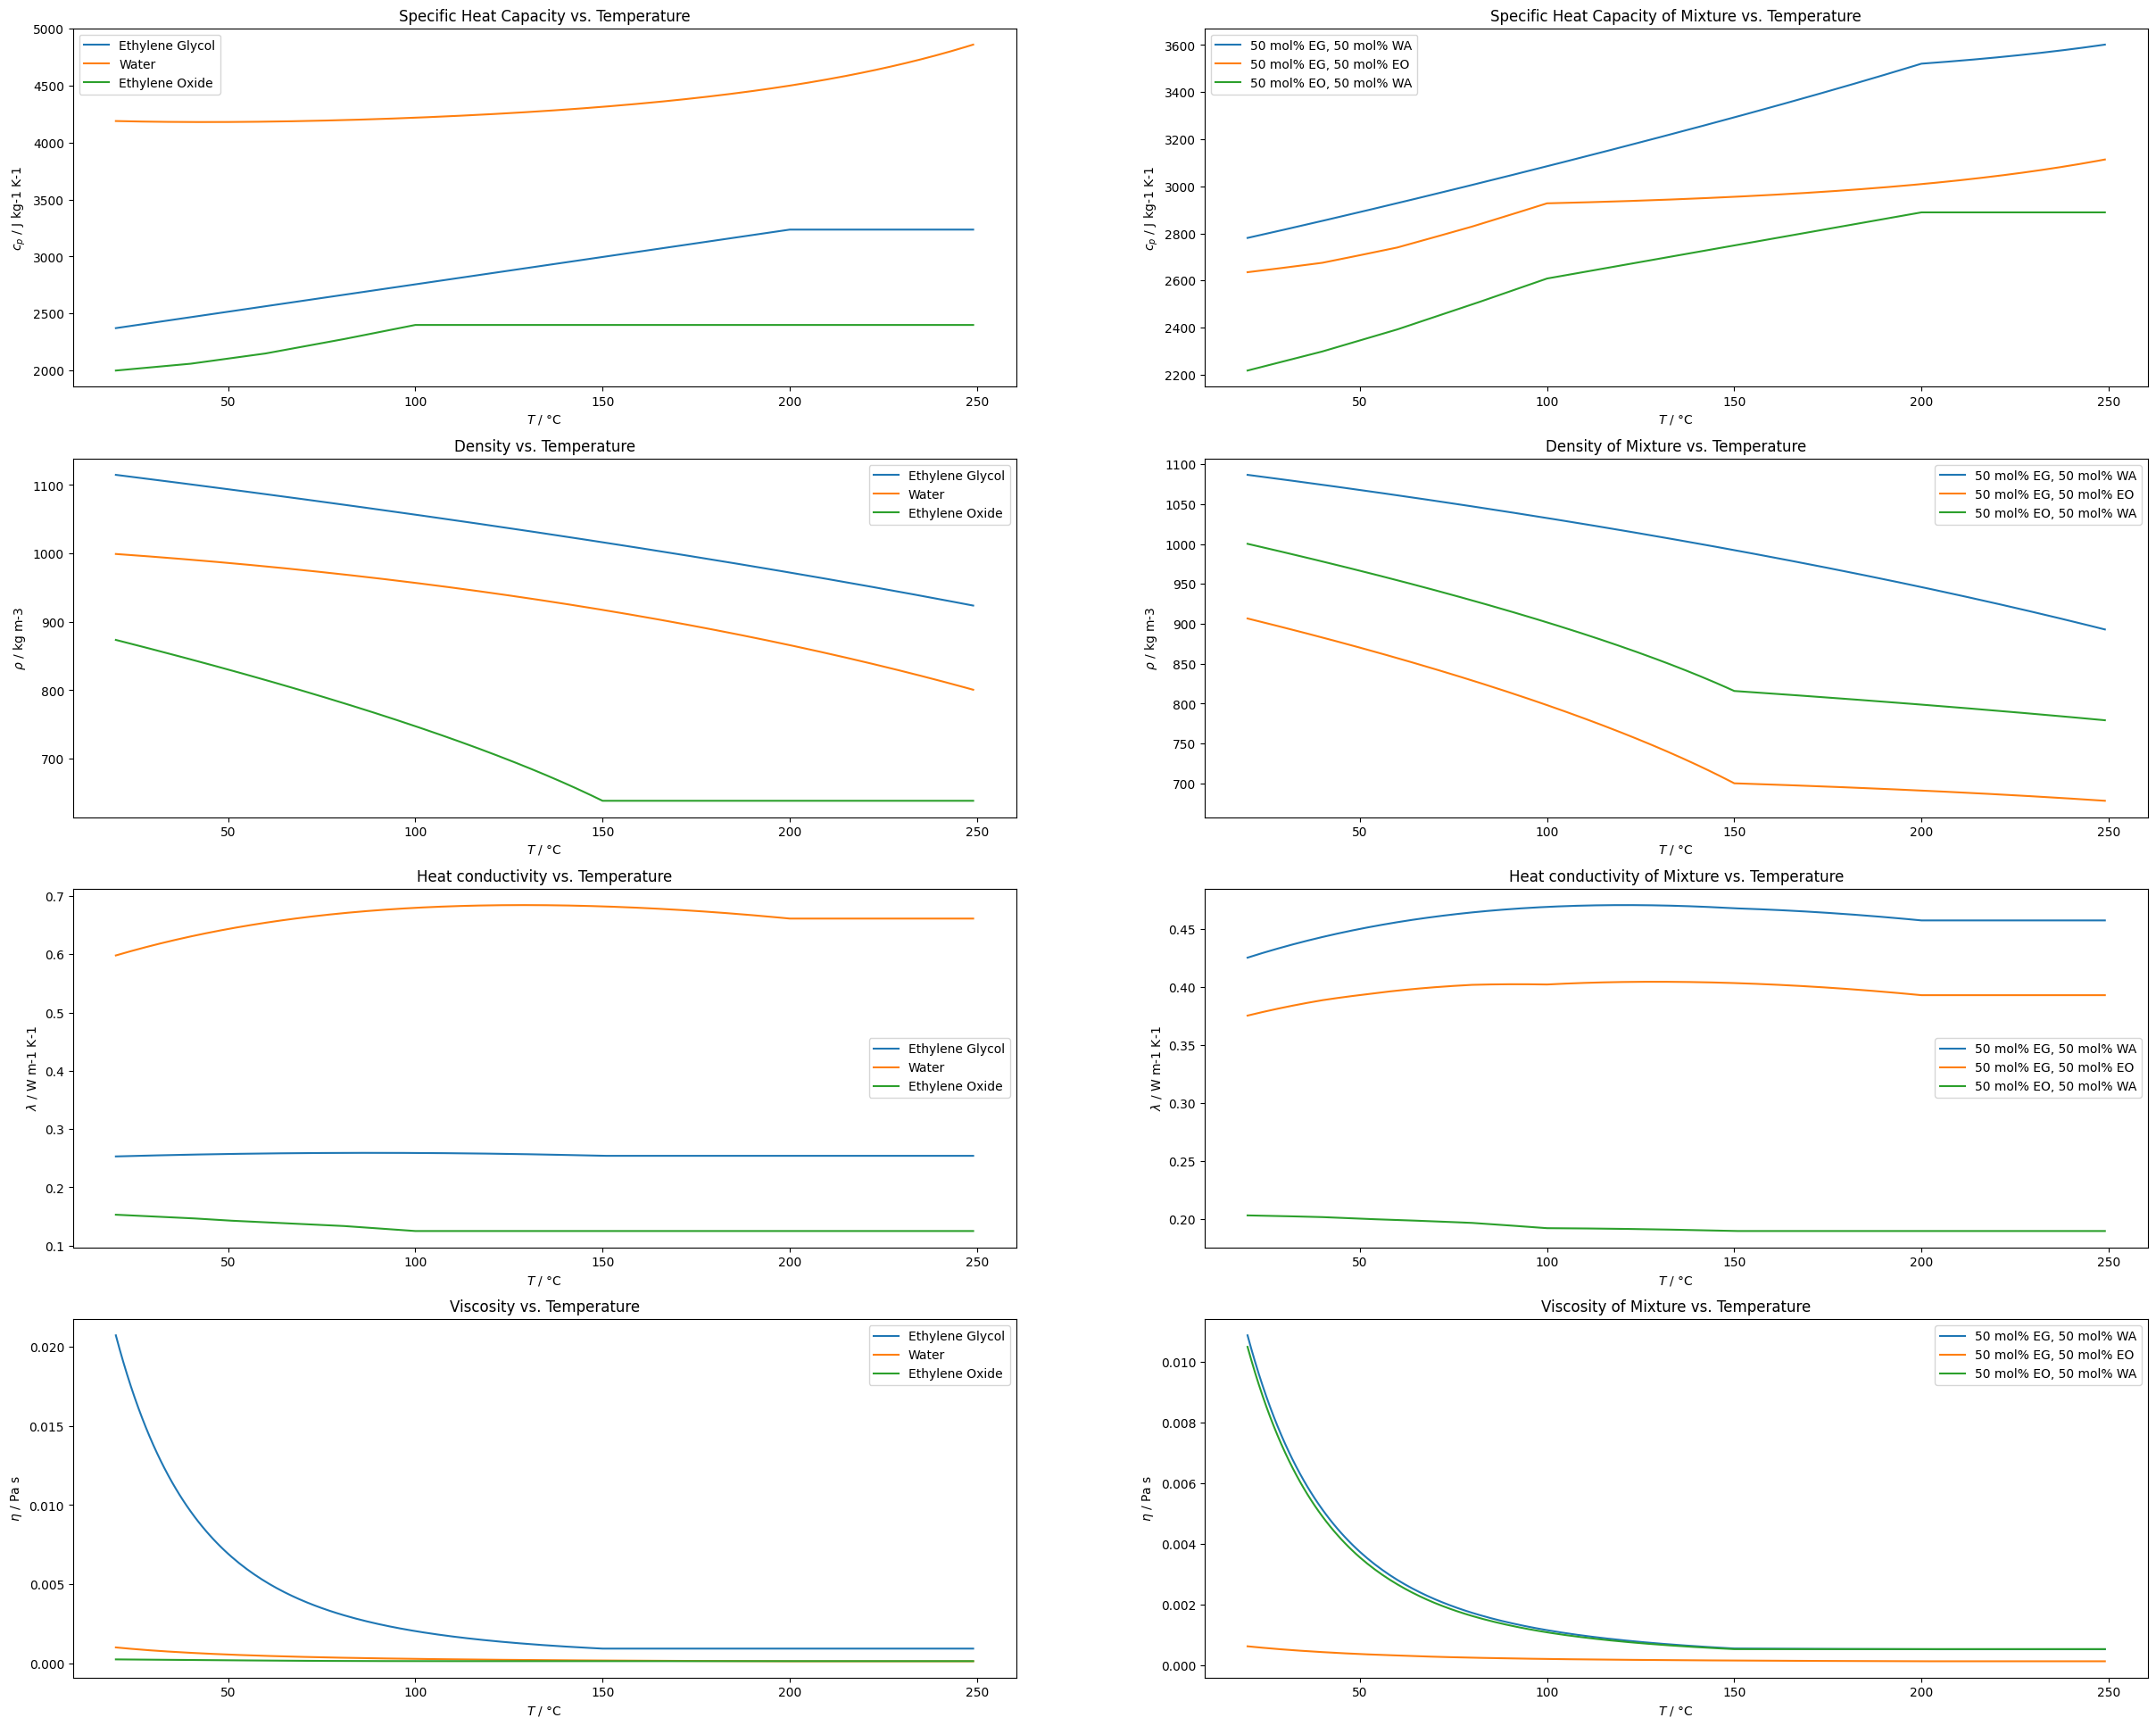

In [89]:
fig, ax = plt.subplots(nrows=4, ncols=2, figsize=(30, 24))
T_range = np.arange(20, 250, 1) + 273.15
ax[0, 0].plot(T_range - 273.15, c_p_EG(T_range), label='Ethylene Glycol')
ax[0, 0].plot(T_range - 273.15, c_p_WA(T_range), label='Water')
ax[0, 0].plot(T_range - 273.15, c_p_EO_interp(T_range), label='Ethylene Oxide')
ax[0, 0].set_xlabel(r'$T$ / °C')
ax[0, 0].set_ylabel(r'$c_p$ / J kg-1 K-1')
ax[0, 0].set_title('Specific Heat Capacity vs. Temperature')
ax[0, 0].legend()

ax[1, 0].plot(T_range - 273.15, rho_EG(T_range), label='Ethylene Glycol')
ax[1, 0].plot(T_range - 273.15, rho_WA(T_range), label='Water')
ax[1, 0].plot(T_range - 273.15, rho_EO(T_range), label='Ethylene Oxide')
ax[1, 0].set_xlabel(r'$T$ / °C')
ax[1, 0].set_ylabel(r'$\rho$ / kg m-3')
ax[1, 0].set_title('Density vs. Temperature')
ax[1, 0].legend()

ax[0, 1].plot(T_range - 273.15, c_p_mix(T_range,  np.array([0.5, 0.5, 0])), label='50 mol% EG, 50 mol% WA')
ax[0, 1].plot(T_range - 273.15, c_p_mix(T_range, np.array([0.5, 0, 0.5])), label='50 mol% EG, 50 mol% EO')
ax[0, 1].plot(T_range - 273.15, c_p_mix(T_range, np.array([0, 0.5, 0.5])), label='50 mol% EO, 50 mol% WA')
ax[0, 1].set_xlabel('$T$ / °C')
ax[0, 1].set_ylabel('$c_p$ / J kg-1 K-1')
ax[0, 1].set_title('Specific Heat Capacity of Mixture vs. Temperature')
ax[0, 1].legend() 

ax[1, 1].plot(T_range - 273.15, rho_mix(T_range, np.array([0.5, 0.5, 0])), label='50 mol% EG, 50 mol% WA')
ax[1, 1].plot(T_range - 273.15, rho_mix(T_range, np.array([0.5, 0, 0.5])), label='50 mol% EG, 50 mol% EO')
ax[1, 1].plot(T_range - 273.15, rho_mix(T_range, np.array([0, 0.5, 0.5])), label='50 mol% EO, 50 mol% WA')
ax[1, 1].set_xlabel(r'$T$ / °C')
ax[1, 1].set_ylabel(r'$\rho$ / kg m-3')
ax[1, 1].set_title('Density of Mixture vs. Temperature')
ax[1, 1].legend()

ax[2, 0].plot(T_range - 273.15, lambda_EG(T_range), label='Ethylene Glycol')
ax[2, 0].plot(T_range - 273.15, lambda_WA(T_range), label='Water')
ax[2, 0].plot(T_range - 273.15, lambda_EO_interp(T_range), label='Ethylene Oxide')
ax[2, 0].set_xlabel(r'$T$ / °C')
ax[2, 0].set_ylabel(r'$\lambda$ / W m-1 K-1')
ax[2, 0].set_title('Heat conductivity vs. Temperature')
ax[2, 0].legend()

ax[2, 1].plot(T_range - 273.15, lambda_mix(T_range, np.array([0.5, 0.5, 0])), label='50 mol% EG, 50 mol% WA')
ax[2, 1].plot(T_range - 273.15, lambda_mix(T_range, np.array([0.5, 0, 0.5])), label='50 mol% EG, 50 mol% EO')
ax[2, 1].plot(T_range - 273.15, lambda_mix(T_range, np.array([0, 0.5, 0.5])), label='50 mol% EO, 50 mol% WA')
ax[2, 1].set_xlabel(r'$T$ / °C')
ax[2, 1].set_ylabel(r'$\lambda$ / W m-1 K-1')
ax[2, 1].set_title('Heat conductivity of Mixture vs. Temperature')
ax[2, 1].legend()

ax[3, 0].plot(T_range - 273.15, eta_EG(T_range), label='Ethylene Glycol')
ax[3, 0].plot(T_range - 273.15, eta_WA(T_range), label='Water')
ax[3, 0].plot(T_range - 273.15, eta_EO_interp(T_range), label='Ethylene Oxide')
ax[3, 0].set_xlabel(r'$T$ / °C')
ax[3, 0].set_ylabel(r'$\eta$ / Pa s')
ax[3, 0].set_title('Viscosity vs. Temperature')
ax[3, 0].legend()

ax[3, 1].plot(T_range - 273.15, eta_mix(T_range, np.array([0.5, 0.5, 0])), label='50 mol% EG, 50 mol% WA')
ax[3, 1].plot(T_range - 273.15, eta_mix(T_range, np.array([0.5, 0, 0.5])), label='50 mol% EG, 50 mol% EO')
ax[3, 1].plot(T_range - 273.15, eta_mix(T_range, np.array([0, 0.5, 0.5])), label='50 mol% EO, 50 mol% WA')
ax[3, 1].set_xlabel(r'$T$ / °C')
ax[3, 1].set_ylabel(r'$\eta$ / Pa s')
ax[3, 1].set_title('Viscosity of Mixture vs. Temperature')
ax[3, 1].legend()

plt.show()

### Converting concentrations to molar flows
For that first the mole fractions used in the thermodynamic models and the inlet molar flows of the injector model the given concentrations have to be converted (Equation 11). 

$$ \dot{n}_i = c_iA_{c}u \tag{11} $$

The concentration of water is generally not given. This leads to the need to calculate it directly. For that first the total molar flow has to be calculated using equations 12-14 and the scipy root solver.

$$ \dot{n}_{mix} = \frac{\dot{m}_{mix}}{M_{mix}} =  \frac{\rho_{mix} \dot{V}}{M_{mix}} = \frac{\rho_{mix} u A_{sqr}}{M_{mix}} \tag{12} $$

$$ \dot{n}_{mix} = \dot{n}_{EO} + \dot{n}_{EG} + \dot{n}_{WA} \tag{13} $$

$$ x_i = \frac{\dot{n}_{i} }{\dot{n}_{mix}} \tag{14} $$





In [90]:
# Calculated molar flow in mol s-1
def n_dot(u, rho, M):
    return u * rho * A_ref / (M * 0.001)

# Calculated liquid velocity in m s-1
def u(n_dot, rho, M):
    return n_dot * M / (rho * A_ref * 1000)

# Molar fraction calculated from concentrations
def x_i(c_arr, c_i):
    return c_i / np.sum(c_arr)

# Function for calculation molar flow of water in mol s-1 via root finding
def search_WA_inlet(n_dot_in_WA, n_dot_in_EO, T_0, u_ref):
    x_WA = n_dot_in_WA / (n_dot_in_WA + n_dot_in_EO)
    x_EO = n_dot_in_EO / (n_dot_in_WA + n_dot_in_EO)

    x_arr = np.array([x_WA[0], 0, x_EO[0]])

    u_ = u(n_dot_in_WA + n_dot_in_EO, rho_mix(T_0, x_arr), M_mix(x_arr))

    return u_ - u_ref

### PFTR behavior with improved thermodynamics
The improved thermodynamic behavior is now applied to the PFTR model. Therefore, the volumetric heat capacity $C_{mix} = \rho_{mix} \cdot c_{p,mix}$ is replaced in the model. The change in fluid velocity $u$ is still assumed to be zero. This can be done because of the generally low coefficients of expansion $(\propto 10^{-4})$ [cite VDI]. 

In [91]:
# Modified ODE of the PFTR with improved thermodynamics
def PFTR_thermodynamics(L, f, u_ref, h):
    """
    Spatial derivatives for the PFTR material and energy balances.

    f[0] = c_1  (EO concentration, mol/m^3)
    f[1] = c_2  (EG concentration, mol/m^3)
    f[2] = c_3  (WA concentration, mol/m^3)
    f[3] = T    (temperature, K)

    Space-time transformation:  d/dL = (1/u) * d/dt
    Each right-hand side is the bSTR time-derivative divided by u.
    """
    c_1 = f[0]
    c_2 = f[1]
    c_3 = f[2]
    T   = f[3]

    c_arr = np.array([c_1, c_2, c_3])

    x_1 = x_i(c_arr, c_1)
    x_2 = x_i(c_arr, c_2)
    x_3 = x_i(c_arr, c_3)

    x_arr = np.array([x_3, x_2, x_1])


    r = kinetics(T, c_1)


    # Component balances (material balance per unit reactor length)
    dc_1dL = -r / u_ref
    dc_2dL =  r / u_ref
    dc_3dL = -r / u_ref

    C = c_p_mix(T, x_arr) * rho_mix(T, x_arr)

    # Energy balance per unit reactor length
    # Reaction term:    -H_R * r / C              [K/s] / [m/s] = K/m
    # Heat-transfer:    h_wall * a_wall * (T-T_wall) / C  [K/m]
    dTdL = (-H_R * r / C - h * a_wall * (T - T_wall) / C) / u_ref

    dfdL = np.empty_like(f)
    dfdL[0] = dc_1dL
    dfdL[1] = dc_2dL
    dfdL[2] = dc_3dL
    dfdL[3] = dTdL
    return dfdL

# Function for  calculating the initial condidion of water and solving the ODE
def sol_thermodynamics(c_arr, T_0, u_ref, h):
    c_EO = c_arr[0] # Concentration of EO in mol/m3
    c_EG = c_arr[1] # Concentration of EO in mol/m3


    n_dot_in_EO_tot = c_EO * u_ref * A_ref # Total molar flow rate of EO in mol/s
    n_dot_in_EG_tot = c_EG * u_ref * A_ref # Total molar flow rate of EO in mol/s

    n_dot_in_WA_initial_guess = n_dot_in_EO_tot # Initial guess for the molar flow rate of water in mol/s    

    n_dot_in_WA = root(search_WA_inlet, n_dot_in_WA_initial_guess, args=(n_dot_in_EO_tot, T_0, u_ref)).x[0] # Solve for the molar flow rate of water in mol/s

    c_WA = n_dot_in_WA / (u_ref * A_ref) # Concentration of water for iitial conditions in mol/m3

    initial = np.array([c_EO, c_EG, c_WA, T_0]) # Initial values for ODE

    sol_thermodynamic = solve_ivp(PFTR_thermodynamics, Lspan, initial, method='LSODA',args=(u_ref, h), t_eval=leval)

    return sol_thermodynamic.t, sol_thermodynamic.y[0], sol_thermodynamic.y[1], sol_thermodynamic.y[2], sol_thermodynamic.y[3] 

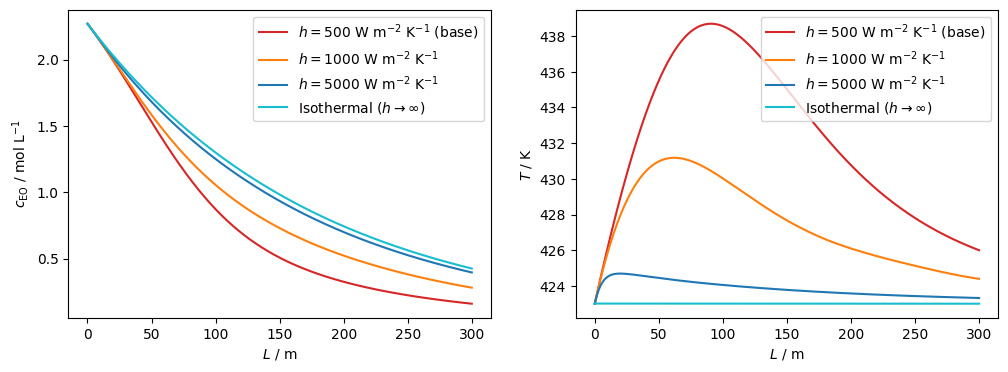

In [92]:
h_cases = {
    '$h = 500$ W m$^{-2}$ K$^{-1}$ (base)': 500,
    '$h = 1000$ W m$^{-2}$ K$^{-1}$': 1000,
    '$h = 5000$ W m$^{-2}$ K$^{-1}$':       5000,
    'Isothermal ($h \\to \\infty$)':         1e6,
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.set(xlabel='$L$ / m', ylabel='$c_{\\mathrm{EO}}$ / mol L$^{-1}$')
ax2.set(xlabel='$L$ / m', ylabel='$T$ / K')
colors = ['tab:red', 'tab:orange', 'tab:blue', 'tab:cyan', 'tab:green']

for (label, h), color in zip(h_cases.items(), colors):
    f_init = np.array([c_10, c_20, T_0])
    sol = sol_thermodynamics(np.array([c_10, c_20]), T_0, u_ref, h)
    ax1.plot(sol[0], sol[1] / 1000, color=color, label=label)
    #ax1.plot(sol[0], sol[2] / 1000, color=color, label=label)
    ax2.plot(sol[0], sol[4],         color=color, label=label)

ax1.legend(loc="best")
ax2.legend(loc="best")

If these results are compared to the PFTR with simplified thermodynamics, there is a higher resulting temperature maximum. This can be explained due to the lower volumetric heat capacity $C_{mix} = c_{p,mix} \cdot \rho_{mix}$ which leads to a higher temperature gradient. This shows that simplifying the thermodynamics leads to an underestimation of the local temperatures and thus the possibility to cross safety limits.

### Improvement of reaction control using multi-jet inlet tubes
One common way in process intensification to control a strongly exothermic reaction is injecting one of the reagents multiple times instead of both reagents at the beginning. This is done because it gives the stream time to get cooled in between injections and thus has the potential to lower or contain the previously observed temperature peaks. For thermodynamics the improved thermodynamics were used.

First the distance $\Delta L$ between the injectors has to be calculated. This is done using the number of injectors $N$ (Equation 15). This number doesn't include the initial injector. The total number of injectors is $N+1$.

$$ \Delta L = \frac{L}{N + 1}  \tag{15} $$

Using the distance between the injectors, the location of injector $i$, $x_{inj, i}$ can be calculated using Equation 16. 

$$ x_{inj, i} =  i \cdot \Delta L \tag{16} $$

Assuming every injection point gets the same amount of reagent, the amount per injector $\dot{n}_{EO, injector}$ is calculated using Equation 17. Due to the difference in concentrations of EO and Water, EO was chosen as injected species. 

$$ \dot{n}_{EO, injector} = \frac{\dot{n}_{EO, in}}{N + 1} \tag{17} $$

For describing the behavior mathematically, molar flow balances are more favorable (Equation 18). A PFTR with multiple injections can be described by multiple consecutive PFTRs with the injector being mixed with the outgoing stream from the previous PFTR. Thus the ODE gets solved for each section. Except for the first section, each initial value was described by the outgoing molar streams of the previous section and the added injection molar streams.

$$ \frac{d\dot{n}_i}{dx} = \nu_i r A_{c} \tag{18}$$

For solving the ODEs, the previous solver and methods were used. Also the kinetics were unchanged. 

In [93]:
A_ref = np.pi * (d_R/2) ** 2 # Crosssection are of the PFTR in m 2

# Calculate the locations for the injectors
def injection_locations(L, N):
    delta_L = L / (N + 1)
    loc = []
    for i in range(1, N + 1):
        loc.append(i*delta_L)
    return loc

# Calculate the molar flow of the PFTR at the reactor inlet in mol/s
def initial_injection(n_dot_in_EO , N):
    return n_dot_in_EO / (N + 1) # Initial flow rate of EO at the first injection point

# ODE for the PFTR including the improved thermodynamics and now based on molar flows
def PFTR_inj(x, f, h, T_w):
    n_dot_WA = f[0]
    n_dot_EG = f[1]
    n_dot_EO = f[2] 
    T = f[3]

    x_WA = n_dot_WA / (n_dot_WA + n_dot_EG + n_dot_EO)
    x_EG = n_dot_EG / (n_dot_WA + n_dot_EG + n_dot_EO)
    x_EO = n_dot_EO / (n_dot_WA + n_dot_EG + n_dot_EO)

    rho_ = rho_mix(T, np.array([x_WA, x_EG, x_EO]))
    c_p_ = c_p_mix(T, np.array([x_WA, x_EG, x_EO])) 

    C = rho_ * c_p_


    u_ = u(n_dot_WA + n_dot_EG + n_dot_EO, rho_mix(T, np.array([x_WA, x_EG, x_EO])), M_mix(np.array([x_WA, x_EG, x_EO])))

    r = kinetics(T, n_dot_EO / (A_ref*u_))

    dn_EO_dotdx = -r * A_ref
    dn_EG_dotdx = r * A_ref
    dn_WA_dotdx = -r * A_ref

    dTdL = (-H_R * r) / (C * u_) - h * a_wall * (T - T_w) / (C * u_)

    dfdL = np.empty_like(f)
    dfdL[0] = dn_WA_dotdx
    dfdL[1] = dn_EG_dotdx
    dfdL[2] = dn_EO_dotdx
    dfdL[3] = dTdL

    return dfdL

delta_x = 0.1
x_prev = 0
L_arr = np.arange(0, L_R, delta_x)

# New temperature after mixing the injector stream with the stream from the PFTR in K
def T_mix(T_new, n_dot_WA_out, n_dot_EO_out, n_dot_EG_out, n_dot_EO_inj, T_inj, T_0):
        
        n_dot_tot = n_dot_WA_out[-1] + n_dot_EO_out[-1] + n_dot_EG_out[-1]
        x_EO_out_ = n_dot_EO_out[-1] / n_dot_tot
        x_EG_out_ = n_dot_EG_out[-1] / n_dot_tot
        x_WA_out_ = n_dot_WA_out[-1] / n_dot_tot

        c_p_mix_out = c_p_mix(T_inj[-1], np.array([x_WA_out_, x_EG_out_, x_EO_out_])) 


        n_dot_tot_new = n_dot_WA_out[-1] + n_dot_EO_out[-1] + n_dot_EG_out[-1] + n_dot_EO_inj
        x_EO_out_new = (n_dot_EO_out[-1] + n_dot_EO_inj) / n_dot_tot_new
        x_EG_out_new = n_dot_EG_out[-1] / n_dot_tot_new
        x_WA_out_new = n_dot_WA_out[-1] / n_dot_tot_new

        M_mix_out = M_mix(np.array([x_WA_out_, x_EG_out_, x_EO_out_]))
        M_mix_out_new = M_mix(np.array([x_WA_out_new, x_EG_out_new, x_EO_out_new]))

        c_p_mix_new = c_p_mix(T_new, np.array([x_WA_out_new, x_EG_out_new, x_EO_out_new])) 

        m_dot_EO_inj = n_dot_EO_inj * M_EO * 10 ** (-3)
        m_dot_out_tot = n_dot_tot * M_mix_out * 10 ** (-3)
        m_dot_out_tot_new = n_dot_tot_new * M_mix_out_new * 10 ** (-3)

        diff = T_new - (m_dot_out_tot* c_p_mix_out * T_inj[-1] + m_dot_EO_inj * c_p_EO_interp(T_0) * T_0) / (m_dot_out_tot_new * c_p_mix_new)

        return diff



# Calculation of PFTR with improved thermodynamics and injectors
def sol_inject(c_arr, T_0, N, h):
    c_EO = c_arr[0]
    c_EG = c_arr[1]


    n_dot_in_EO_tot = c_EO * u_ref * A_ref # Total molar flow rate of EO in mol/s
    n_dot_in_EG_tot = c_EG * u_ref * A_ref # Total molar flow rate of EO in mol/s

    x_arr_inj = injection_locations(L_R, N)
    n_dot_in_EO_injection = n_dot_in_EO_tot / (N + 1) # Flow rate of EO at each injection point

    arr = {} # x array for each section

    delta_L = L_R / (N + 1)

    # Calculating the x array for each section
    for i, x_i in enumerate(x_arr_inj):
        t_arr = np.arange(i*delta_L, (i+1)*delta_L, 0.1)
        arr.update({f"{i}": t_arr})

    numb = N 


    arr.update({f"{numb}": np.arange(numb*delta_L, (numb+1)*delta_L, 0.1)}) # Adding one section due to N + 2 sections required

    n_dot_in_EO = initial_injection(n_dot_in_EO_tot, N) # Molar flow rate of EO at each injection point in mol/s

    n_dot_in_WA_initial_guess = n_dot_in_EO # Initial guess for the molar flow rate of water in mol/s    

    n_dot_in_WA = root(search_WA_inlet, n_dot_in_WA_initial_guess, args=(n_dot_in_EO, T_0, 1)).x[0] # Solve for the molar flow rate of water in mol/s

    n_dot_WA_out = np.array([n_dot_in_WA]) # Resulting molar flow profile of water in mol/s
    n_dot_EG_out = np.array([0]) # Resulting molar flow profile of EG in mol/s
    n_dot_EO_out = np.array([0]) # Resulting molar flow profile of EO in mol/s
    T_inj = np.array([T_0]) # Resulting temperature profile in K
    t = np.array([0])

    # Solving the ODE for each section of the PFTR
    for i in arr.keys():
        L_arr = arr[f"{i}"]

        T_w = T_0


        if int(i) > 0:
            T_mix_ = root(T_mix, T_inj[-1], args=(n_dot_WA_out, n_dot_EO_out, n_dot_EG_out, n_dot_in_EO, T_inj, T_0)).x[0]

        else:
            T_mix_ = T_0

        initial = np.array([n_dot_WA_out[-1], n_dot_EG_out[-1], n_dot_EO_out[-1] + n_dot_in_EO , T_mix_])
        sol_inj = solve_ivp(PFTR_inj, np.array([L_arr[0], L_arr[-1]]), initial, t_eval=L_arr, method="BDF", max_step=0.1, args=(h, T_w))

        t = np.append(t , sol_inj.t)
        n_dot_WA_out = np.append(n_dot_WA_out, sol_inj.y[0])
        n_dot_EG_out = np.append(n_dot_EG_out, sol_inj.y[1])
        n_dot_EO_out = np.append(n_dot_EO_out, sol_inj.y[2])
        T_inj = np.append(T_inj, sol_inj.y[3])


    x_WA_inj_out = n_dot_WA_out / (n_dot_WA_out + n_dot_EO_out + n_dot_EG_out) # Mole fraction profile of water in the resulting stream
    x_EO_inj_out = n_dot_EO_out / (n_dot_WA_out + n_dot_EO_out + n_dot_EG_out) # Mole fraction profile of EO in the resulting stream
    x_EG_inj_out = n_dot_EG_out / (n_dot_WA_out + n_dot_EO_out + n_dot_EG_out) # Mole fraction profile of EG in the resulting stream


    u_ = u(n_dot_WA_out+n_dot_EG_out+n_dot_EO_out, rho_mix(T_inj, np.array([x_WA_inj_out, x_EG_inj_out, x_EO_inj_out])), M_mix(np.array([x_WA_inj_out, x_EG_inj_out, x_EO_inj_out]))) # Velocity profile of the resulting stream profile
    
    return t, n_dot_WA_out / (u_ * A_ref), n_dot_EG_out / (u_ * A_ref), n_dot_EO_out / (u_ * A_ref), T_inj, u_





# %%


### Influence of different heat transfer coefficients 
Because the injector PFTR improves heat transfer, lower wall heat transfer coefficients $k_{wall}$ may be sufficient. It is therefore important to determine how low the heat transfer coefficient can be before temperature rises sharply. Furthermore, a higher inlet temperature $T_0$ is chosen to bring the system closer to a more optimal operating point. 

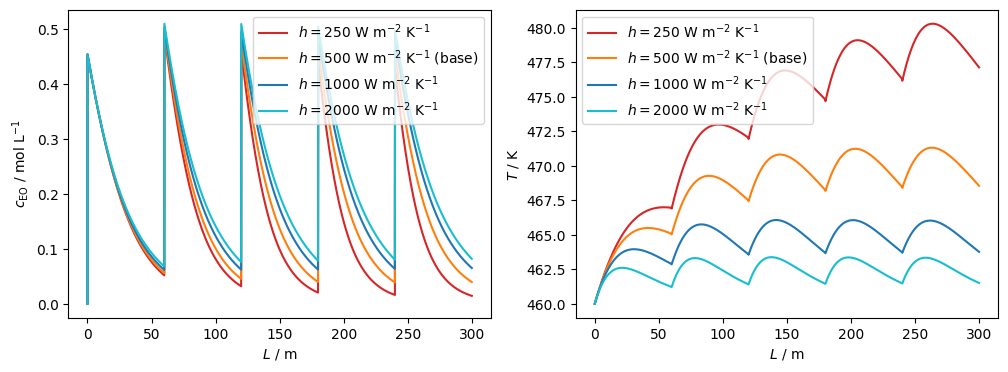

In [94]:
h_cases_inj = {
    '$h = 250$ W m$^{-2}$ K$^{-1}$': 250,
    '$h = 500$ W m$^{-2}$ K$^{-1}$ (base)': 500,
    '$h = 1000$ W m$^{-2}$ K$^{-1}$': 1000,
    '$h = 2000$ W m$^{-2}$ K$^{-1}$': 2000,
}


fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(12, 4))
ax3.set(xlabel='$L$ / m', ylabel='$c_{\\mathrm{EO}}$ / mol L$^{-1}$')
ax4.set(xlabel='$L$ / m', ylabel='$T$ / K')
colors = ['tab:red', 'tab:orange', 'tab:blue', 'tab:cyan', 'tab:green']

for (label, h), color in zip(h_cases_inj.items(), colors):
    sol_inj = sol_inject(np.array([c_10, c_20]), 460, 4, h)
    ax3.plot(sol_inj[0], sol_inj[3] / 1000, color=color, label=label)
    #ax3.plot(sol_inj[0], sol_inj[2] / 1000, color=color, label=label)
    ax4.plot(sol_inj[0], sol_inj[4],         color=color, label=label)

ax3.legend(loc="best")
ax4.legend(loc="best")

plt.show()

Here it can be seen that concentrations decline strongly between injection points. A lower heat transfer coefficient leads to higher reactant consumption. Comparing this with the temperature behavior, the higher heat transfer coefficient keeps the temperature closer to the setpoint, while the lower coefficient cannot prevent the temperature increase. Thus, the temperature rise leads to greater reactant consumption.

### Influence of the amount of injectors
Now it is important to look at the effect of different numbers of injectors. This is important because a higher number of injectors has the potential of increasing reaction control. 

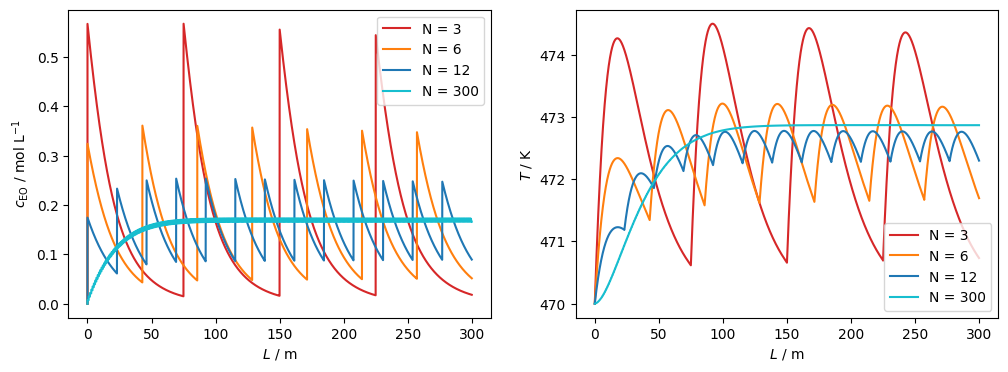

In [95]:
N_cases = {
    "N = 3": 3,
    "N = 6": 6,
    "N = 12": 12,
    "N = 300": 300,
}

fig3, (ax5, ax6) = plt.subplots(1, 2, figsize=(12, 4))
ax5.set(xlabel='$L$ / m', ylabel='$c_{\\mathrm{EO}}$ / mol L$^{-1}$')
ax6.set(xlabel='$L$ / m', ylabel='$T$ / K')
colors = ['tab:red', 'tab:orange', 'tab:blue', 'tab:cyan', 'tab:green']

for (label, N), color in zip(N_cases.items(), colors):
    sol_inj_c = sol_inject(np.array([c_10, c_20]), 470, N, 2000)

    ax5.plot(sol_inj_c[0], sol_inj_c[3] / 1000, color=color, label=label)
    ax6.plot(sol_inj_c[0], sol_inj_c[4],         color=color, label=label)

ax5.legend(loc="best")
ax6.legend(loc="best")

plt.show()

Here we see that with a larger number of injectors the PFTR behavior approaches a smooth curve. This can be explained by the fact that the PFTR approaches the behavior of a semi-continuous batch reactor as $N \to \infty$. Thus it can be said that a higher number of injectors improves the reaction control and thus fulfills the requirements of process intensification. 

### Optimization of the PFTR with injectors
Now it is important to determine how large the temperature increase is relative to the conversion. This is a typical case of process control versus process performance. Higher temperatures mean higher thermal requirements for the reactor and a greater risk of increased production of side products.

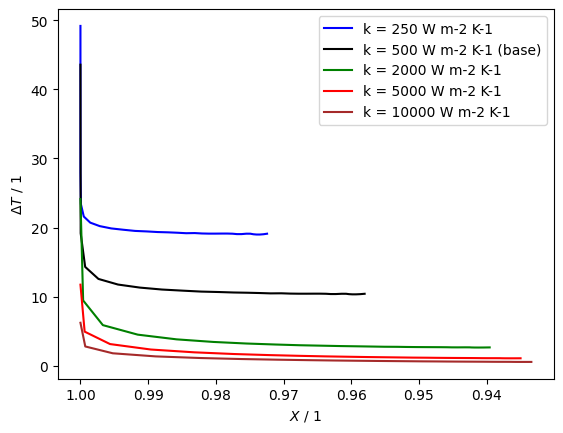

In [96]:
fig_par, ax_par = plt.subplots()

ax_par.invert_xaxis()

h_arr = np.array([250, 500, 2000, 5000, 10000]) # Array of heat transfer coefficient in W m-2 K-1
N_arr = np.arange(0, 30, 1) # Array of number of injectors

color = ["blue", "black", "green", "red", "brown"]
label = [r"k = 250 W m-2 K-1", r"k = 500 W m-2 K-1 (base)", r"k = 2000 W m-2 K-1", r"k = 5000 W m-2 K-1", r"k = 10000 W m-2 K-1"]

for i, h in enumerate(h_arr):
    U_final_N = np.array([])
    delta_T_N = np.array([])
    for N in N_arr:
        sol_inj_c = sol_inject(np.array([c_10, c_20]), 470, N, h) # Solving the ODE 

        n_dot_in_EO_tot = c_10 * u_ref * A_ref # Total molar flow of EO added of each case
        n_dot_EO_out = sol_inj_c[3][-1] * sol_inj_c[5][-1] * A_ref # Outgoing stream of EO at the exit of the PFTR of each case

        len_arr = len(sol_inj_c[4])

        U_final = (n_dot_in_EO_tot - n_dot_EO_out) / n_dot_in_EO_tot # Conversion at the exit of the PFTR of each case
        delta_T =  np.max(sol_inj_c[4]) - 470 # Deviations from temperature setpoint in K

        U_final_N = np.append(U_final_N, U_final)
        delta_T_N = np.append(delta_T_N, delta_T)

    ax_par.plot(U_final_N, delta_T_N, color=color[i], label=label[i])
    ax_par.set(xlabel=r"$X$ / 1", ylabel=r"$\Delta T$ / 1")

ax_par.legend(loc="best")
plt.show()


The optimization seems to form a variety of Pareto fronts, which are typical for multi-objective optimization and shows the limits of process intensification. This indicates that injectors are needed in the case of poor heat exchange performance. It also means that if the reaction is more exothermic than assumed, injectors are still needed to control temperature. 